# Part 4 — Trying to Break My Own Result

### Does WaveHAR survive a properly fitted HAR and modern HAR extensions?

**Ahmet Kaçmaz**

---

Part 3 reported that WaveHAR beats HAR-RV (R² 0.475 vs 0.463, Diebold–Mariano *p* = 0.026), with
the margin growing at longer horizons. Before believing that, one question has to be answered:

> **Was the HAR I beat the *best* HAR — or just the most convenient one?**

This is not a rhetorical worry. Audrino & Chassot (2024), *"HARd to Beat: The Overlooked Impact of
Rolling Windows in the Era of Machine Learning"*, tested machine-learning models against HAR on
**1,455 stocks** and found that ML models **fail to beat HAR once HAR is given a properly specified
fitting scheme** — the training-window length and the re-estimation frequency. Their conclusion is
blunt: a large share of the reported "we beat HAR" results in the literature are beating a
carelessly fitted HAR.

In Part 3 my HAR was estimated **once**, on a fixed training period, and then frozen for three
years of test data. That is exactly the fitting scheme their paper criticises. So my headline
result is currently open to the most obvious rebuttal there is.

This notebook removes that rebuttal by making the benchmark as strong as I know how to make it:

1. **A fitting-scheme grid.** Rolling and expanding windows × re-estimation frequencies, applied to
   *every* model, so HAR is fitted the way its own advocates say it should be.
2. **Modern HAR extensions.** Plain HAR is a 2009 model. The field has moved on to leverage and
   jump components; both are added (with daily-data analogues — see the limitations section).
3. **Honest scheme selection.** The winning fitting scheme is chosen on a **validation window
   inside the training period** — never on the test set. Picking the scheme that happens to look
   best on test would be the same class of error this whole project is about.

**I do not know how this ends.** If WaveHAR's advantage was an artifact of a badly fitted
benchmark, it should die here — and I will report that. The conclusions at the bottom are printed
from the computed results either way.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import t as t_dist

SEED = 0
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

## 1. Data and predictors

Same Garman–Klass log realized volatility as Parts 2–3, plus two extra predictors that plain
HAR ignores and that the modern HAR family relies on:

- **Leverage** — negative returns raise future volatility more than positive ones
  (Corsi & Renò). Proxy: $\min(r_t, 0)$.
- **Jumps** — the discontinuous part of the price path is *less* persistent than the diffusive
  part, so separating it improves forecasts (Andersen–Bollerslev–Diebold). Proxy:
  the **overnight gap** $|\log(O_t / C_{t-1})|$, which is the one genuinely discontinuous move
  observable in daily OHLC data.

In [2]:
ASSETS = {"S&P 500": "gspc", "Dow Jones": "dji", "NASDAQ": "ixic",
          "DAX": "gdaxi", "FTSE 100": "ftse", "Nikkei 225": "n225"}

TEST_FRAC = 0.2
VAL_FRAC = 0.25          # last quarter of the TRAIN period, used only to choose the fitting scheme
J = 5                    # à trous levels
FIRST = 128
K_FRAC = 100


def load_asset(key):
    df = pd.read_csv(f"../data/{key}.csv", index_col="Date", parse_dates=True)
    ok = (df["High"] > df["Low"]) & (df[["Open", "High", "Low", "Close"]] > 0).all(axis=1)
    df = df[ok]
    O, H, L, C = (np.array(df[k].to_numpy(), float) for k in ("Open", "High", "Low", "Close"))
    gk = 0.5 * np.log(H / L) ** 2 - (2 * np.log(2) - 1) * np.log(C / O) ** 2
    pos = gk > 0
    df, gk, O, C = df[pos], gk[pos], O[pos], C[pos]

    r = np.diff(np.log(C))
    lrv = 0.5 * np.log(gk)[1:]
    overnight = np.log(O[1:] / C[:-1])          # aligned with r: the gap that opened day t
    return dict(dates=df.index[1:], r=r, lrv=lrv, overnight=overnight,
                split=int(len(lrv) * (1 - TEST_FRAC)))


spx = load_asset("gspc")
lrv, r, overnight, split = spx["lrv"], spx["r"], spx["overnight"], spx["split"]
dates, T = spx["dates"], len(lrv)
val_start = int(split * (1 - VAL_FRAC))

print(f"S&P 500: {T} days")
print(f"  train-core : {0:>5} … {val_start:>5}   ({dates[0].date()} → {dates[val_start-1].date()})")
print(f"  validation : {val_start:>5} … {split:>5}   ({dates[val_start].date()} → {dates[split-1].date()})"
      f"   ← the fitting scheme is chosen here")
print(f"  test       : {split:>5} … {T:>5}   ({dates[split].date()} → {dates[-1].date()})"
      f"   ← touched only once, at the end")

S&P 500: 3521 days
  train-core :     0 …  2112   (2010-01-05 → 2018-05-24)
  validation :  2112 …  2816   (2018-05-25 → 2021-03-12)   ← the fitting scheme is chosen here
  test       :  2816 …  3521   (2021-03-15 → 2023-12-29)   ← touched only once, at the end


In [3]:
def haar_atrous(x, levels=J):
    """Causal Haar à trous transform (Part 3). Row t uses only x[:t+1]."""
    x = np.asarray(x, float)
    c = x.copy()
    cols = []
    for j in range(levels):
        lag = 2 ** j
        c_next = c.copy()
        c_next[lag:] = 0.5 * (c[lag:] + c[:-lag])
        cols.append(c - c_next)
        c = c_next
    cols.append(c)
    return np.column_stack(cols)


def rolling_mean(x, w):
    cs = np.concatenate([[0.0], np.cumsum(x)])
    out = np.full(len(x), np.nan)
    out[w - 1:] = (cs[w:] - cs[:-w]) / w
    return out


def lagged(x, lag):
    out = np.full(len(x), np.nan)
    if lag == 0:
        return np.asarray(x, float).copy()
    out[lag:] = x[:-lag]
    return out


def target_h(x, h):
    """y[t] = mean of x over days t+1 … t+h."""
    cs = np.concatenate([[0.0], np.cumsum(x)])
    y = np.full(len(x), np.nan)
    tt = np.arange(0, len(x) - h)
    y[tt] = (cs[tt + 1 + h] - cs[tt + 1]) / h
    return y


def build_features(lrv, r, overnight):
    comps = haar_atrous(lrv)
    lev = np.minimum(r, 0.0)                       # leverage proxy
    jmp = np.abs(overnight)                        # jump proxy (overnight gap)
    extras = np.column_stack([lev, rolling_mean(lev, 5), jmp, rolling_mean(jmp, 5)])

    har = np.column_stack([lrv, rolling_mean(lrv, 5), rolling_mean(lrv, 22)])
    harx = np.column_stack([lagged(lrv, k) for k in (0, 1, 2, 4, 9, 21)])
    return {
        "HAR": har,
        "HAR-X (6 lags)": harx,
        "HAR-LJ (+lev +jump)": np.column_stack([har, extras]),
        "WaveHAR": comps,
        "WaveHAR-LJ (+lev +jump)": np.column_stack([comps, extras]),
    }


FEATS = build_features(lrv, r, overnight)
for k, v in FEATS.items():
    print(f"  {k:<26} {v.shape[1]:>2} features")

  HAR                         3 features
  HAR-X (6 lags)              6 features
  HAR-LJ (+lev +jump)         7 features
  WaveHAR                     6 features
  WaveHAR-LJ (+lev +jump)    10 features


## 2. The fitting-scheme grid

For a forecast made at origin $t$ over horizon $h$, only origins $s$ with $s + h \le t$ have a
fully observed target — so the training set is $s \in [\,t-h-W+1,\; t-h\,]$ for a rolling window of
length $W$, or everything up to $t-h$ for an expanding window. Coefficients are refreshed every
`refit_every` days and reused in between.

This is the machinery Part 3 lacked: there, one fit was made on the training period and frozen for
the entire three-year test set.

In [4]:
WINDOWS = [None, 500, 1000, 1500, 2000]          # None = expanding
REFITS = [1, 5, 22]                              # re-estimation frequency, in days
MIN_TRAIN = 250


def rolling_ols(X, y, origins, eval_mask, window, refit_every, h):
    """Forecast y at the origins selected by eval_mask, refitting on a rolling/expanding window.

    Every training target is fully observed at the moment the forecast is made.
    """
    preds = np.full(eval_mask.sum(), np.nan)
    coef = intercept = None
    steps_since_fit = np.inf

    for i, t in enumerate(origins[eval_mask]):
        usable = origins[origins <= t - h]                     # targets already observed at time t
        if window is not None:
            usable = usable[usable >= t - h - window + 1]
        if len(usable) < MIN_TRAIN:
            continue

        if steps_since_fit >= refit_every:
            lin = LinearRegression().fit(X[usable], y[usable])
            coef, intercept = lin.coef_, lin.intercept_
            steps_since_fit = 0
        steps_since_fit += 1
        preds[i] = X[t] @ coef + intercept
    return preds


def qlike(y, p):
    return np.mean(np.exp(y - p) - (y - p) - 1)


def dm_hac(y, p1, p2, h):
    """Diebold–Mariano on squared error, Newey–West (Bartlett, bw=h) + Harvey correction."""
    d = (y - p1) ** 2 - (y - p2) ** 2
    n = len(d)
    db, dc = d.mean(), d - d.mean()
    s = np.mean(dc ** 2)
    for lag in range(1, h):
        s += 2 * (1 - lag / h) * np.mean(dc[lag:] * dc[:-lag])
    stat = db / np.sqrt(max(s, 1e-30) / n)
    stat *= np.sqrt(max(n + 1 - 2 * h + h * (h - 1) / n, 1) / n)
    return stat, 2 * (1 - t_dist.cdf(abs(stat), df=n - 1))


def grid_for(model, h, eval_from, eval_to, lrv=lrv, feats=None):
    """Evaluate every fitting scheme for one model on the origins in [eval_from, eval_to)."""
    feats = feats or FEATS
    X, y = feats[model], target_h(lrv, h)
    origins = np.arange(FIRST, len(lrv) - h)
    mask = (origins >= eval_from) & (origins < eval_to)
    yt = y[origins[mask]]

    rows = {}
    for w in WINDOWS:
        for rf in REFITS:
            p = rolling_ols(X, y, origins, mask, w, rf, h)
            ok = ~np.isnan(p)
            rows[(w, rf)] = dict(r2=r2_score(yt[ok], p[ok]), qlike=qlike(yt[ok], p[ok]),
                                 pred=p, y=yt, ok=ok)
    return rows

### How much does the fitting scheme matter to HAR?

Evaluated on the **validation window** (inside the training period). If Audrino & Chassot are
right, HAR should improve materially when it is refitted on a rolling window — and Part 3's frozen
fit should look like one of the weaker choices.

In [5]:
H_MAIN = 1
grid_har = grid_for("HAR", H_MAIN, val_start, split)
grid_wav = grid_for("WaveHAR", H_MAIN, val_start, split)


def grid_table(grid, label):
    tab = pd.DataFrame(
        [[grid[(w, rf)]["r2"] for rf in REFITS] for w in WINDOWS],
        index=[("expanding" if w is None else f"rolling {w}") for w in WINDOWS],
        columns=[f"refit every {rf}d" for rf in REFITS])
    tab.index.name = f"{label}: validation R²"
    return tab


print(grid_table(grid_har, "HAR").round(4).to_string())
print()
print(grid_table(grid_wav, "WaveHAR").round(4).to_string())

har_spread = max(v["r2"] for v in grid_har.values()) - min(v["r2"] for v in grid_har.values())
print(f"\nHAR's validation R² swings by {har_spread:.4f} across fitting schemes.")
print("The benchmark's own configuration matters. Choosing it carelessly is how a weak")
print("benchmark gets beaten — which is exactly the critique this notebook is answering.")

                    refit every 1d  refit every 5d  refit every 22d
HAR: validation R²                                                 
expanding                   0.5518          0.5511           0.5497
rolling 500                 0.5580          0.5568           0.5536
rolling 1000                0.5563          0.5555           0.5527
rolling 1500                0.5563          0.5555           0.5536
rolling 2000                0.5522          0.5514           0.5495

                        refit every 1d  refit every 5d  refit every 22d
WaveHAR: validation R²                                                 
expanding                       0.5608          0.5602           0.5588
rolling 500                     0.5638          0.5630           0.5601
rolling 1000                    0.5636          0.5629           0.5604
rolling 1500                    0.5631          0.5624           0.5606
rolling 2000                    0.5607          0.5600           0.5582

HAR's validation R

### Choosing each model's scheme — on validation, never on test

Each model gets the fitting scheme that maximises its **validation** R². Every model gets the same
privilege, so no model is handicapped, and the test set is untouched by the choice.

In [6]:
MODELS = list(FEATS)
best_scheme = {}
for m in MODELS:
    g = grid_for(m, H_MAIN, val_start, split)
    best_scheme[m] = max(g, key=lambda k: g[k]["r2"])

print(f"Fitting scheme selected on the validation window (h={H_MAIN}):\n")
for m in MODELS:
    w, rf = best_scheme[m]
    print(f"  {m:<26} → {'expanding' if w is None else f'rolling {w}d':<14} refit every {rf}d")
print(f"\n  (Part 3 used, for every model: one fit on the whole training period, never refreshed.)")

Fitting scheme selected on the validation window (h=1):

  HAR                        → rolling 500d   refit every 1d
  HAR-X (6 lags)             → rolling 1500d  refit every 1d
  HAR-LJ (+lev +jump)        → rolling 500d   refit every 1d
  WaveHAR                    → rolling 500d   refit every 1d
  WaveHAR-LJ (+lev +jump)    → rolling 500d   refit every 1d

  (Part 3 used, for every model: one fit on the whole training period, never refreshed.)


## 3. ARFIMA, also refitted

ARFIMA was Part 3's other strong benchmark and it too was frozen. Here $d$ and the ARMA parameters
are re-estimated on an expanding window every 125 days.

In [7]:
def gph_d(x, power=0.6):
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    m = int(n ** power)
    I = np.abs(np.fft.rfft(x)) ** 2 / (2 * np.pi * n)
    lam = 2 * np.pi * np.arange(1, m + 1) / n
    Xr = np.log(4 * np.sin(lam / 2) ** 2).reshape(-1, 1)
    return -LinearRegression().fit(Xr, np.log(I[1:m + 1])).coef_[0]


def frac_weights(d, K=K_FRAC):
    w = np.zeros(K + 1)
    w[0] = 1.0
    for k in range(1, K + 1):
        w[k] = w[k - 1] * (k - 1 - d) / k
    return w


def _frac_diff_series(x, w):
    """(1-L)^d x for the whole series. fd[s] uses only x[s-K … s], so it stays causal."""
    K = len(w) - 1
    fd = np.full(len(x), np.nan)
    for s in range(K, len(x)):
        fd[s] = np.dot(w, x[s - K:s + 1][::-1])
    return fd


def arfima_rolling(lrv, eval_from, eval_to, h, refit_every=125):
    """Refit ARFIMA (d and the ARMA) on an expanding window; forecast the h-day average.

    d and the ARMA parameters at any origin are estimated only from data before that origin, and the
    MA innovation is carried through the full recursion rather than being zeroed out — the benchmark
    is meant to be as strong as I can make it, not conveniently weak.
    """
    origins = np.arange(FIRST, len(lrv) - h)
    mask = (origins >= eval_from) & (origins < eval_to)
    out = np.full(mask.sum(), np.nan)
    state = None

    for i, t in enumerate(origins[mask]):
        if state is None or (t - eval_from) % refit_every == 0:
            hist = lrv[:t + 1]                                    # strictly past-and-present
            d = float(np.clip(gph_d(hist), 0.01, 0.99))
            w = frac_weights(d)
            fd_fit = _frac_diff_series(hist, w)
            arma = ARIMA(fd_fit[K_FRAC:], order=(1, 0, 1)).fit()
            pr = dict(zip(arma.param_names, arma.params))
            ar, ma, mu = pr.get("ar.L1", 0.0), pr.get("ma.L1", 0.0), pr.get("const", 0.0)

            # fd over the whole sample using these (past-estimated) weights — each entry is causal
            fd_all = _frac_diff_series(lrv, w)
            eps = np.zeros(len(lrv))
            for s in range(K_FRAC + 1, len(lrv)):
                pred = mu + ar * (fd_all[s - 1] - mu) + ma * eps[s - 1]
                eps[s] = fd_all[s] - pred
            state = dict(w=w, ar=ar, ma=ma, mu=mu, fd=fd_all, eps=eps)

        w, ar, ma, mu, fd, eps = (state[k] for k in ("w", "ar", "ma", "mu", "fd", "eps"))
        f = mu + ar * (fd[t] - mu) + ma * eps[t]                  # one-step ahead in fd space

        buf = list(lrv[t - K_FRAC + 1:t + 1])
        path = np.empty(h)
        for s in range(h):
            if s > 0:
                f = mu + ar * (f - mu)
            val = f - np.dot(w[1:], np.array(buf[::-1]))          # invert (1-L)^d
            path[s] = val
            buf.pop(0)
            buf.append(val)
        out[i] = path.mean()
    return out

## 4. The verdict at h = 1

Every model, under its own validation-chosen fitting scheme, on the untouched test set.

In [8]:
def evaluate_all(h, lrv=lrv, feats=None, schemes=None, label="S&P 500"):
    feats = feats or FEATS
    schemes = schemes or best_scheme
    y = target_h(lrv, h)
    origins = np.arange(FIRST, len(lrv) - h)
    mask = origins >= split
    yt = y[origins[mask]]

    preds = {}
    for m in feats:
        w, rf = schemes.get(m, (None, 1))
        preds[m] = rolling_ols(feats[m], y, origins, mask, w, rf, h)
    preds["ARFIMA (refitted)"] = arfima_rolling(lrv, split, len(lrv), h)

    ok = np.all([~np.isnan(p) for p in preds.values()], axis=0)
    return {k: v[ok] for k, v in preds.items()}, yt[ok], origins[mask][ok]


preds1, y1, te1 = evaluate_all(H_MAIN)

rows = []
for m, p in preds1.items():
    rows.append({"model": m, "R²": r2_score(y1, p), "RMSE": np.sqrt(mean_squared_error(y1, p)),
                 "QLIKE": qlike(y1, p)})
res1 = pd.DataFrame(rows).set_index("model").sort_values("R²", ascending=False)
display(res1.style.format({"R²": "{:+.4f}", "RMSE": "{:.4f}", "QLIKE": "{:.5f}"})
        .background_gradient(subset=["R²"], cmap="Greens"))

print(f"\nWaveHAR against every strengthened benchmark (h={H_MAIN}, n={len(y1)}):\n")
verdicts1 = {}
for rival in [m for m in preds1 if m != "WaveHAR"]:
    s, pv = dm_hac(y1, preds1["WaveHAR"], preds1[rival], H_MAIN)
    verdicts1[rival] = (s, pv)
    tag = ("WaveHAR better" if s < 0 else "RIVAL BETTER") if pv < 0.05 else "indistinguishable"
    print(f"  vs {rival:<26} stat={s:+6.2f}  p={pv:.4f}   → {tag}")

,R²,RMSE,QLIKE
model,,,
WaveHAR-LJ (+lev +jump),+0.4934,0.3938,0.08040
HAR-LJ (+lev +jump),+0.4861,0.3966,0.08166
ARFIMA (refitted),+0.4729,0.4017,0.08479
WaveHAR,+0.4658,0.4044,0.08487
HAR-X (6 lags),+0.4605,0.4064,0.08802
HAR,+0.4567,0.4078,0.08668



WaveHAR against every strengthened benchmark (h=1, n=704):

  vs HAR                        stat= -1.51  p=0.1327   → indistinguishable
  vs HAR-X (6 lags)             stat= -0.88  p=0.3796   → indistinguishable
  vs HAR-LJ (+lev +jump)        stat= +1.91  p=0.0564   → indistinguishable
  vs WaveHAR-LJ (+lev +jump)    stat= +3.00  p=0.0028   → RIVAL BETTER
  vs ARFIMA (refitted)          stat= +1.29  p=0.1967   → indistinguishable


## 5. And at h = 22, where Part 3's claim was strongest

Part 3's most confident finding was that WaveHAR's edge *grows* with horizon (significant at
h = 22, *p* = 0.004). A monthly horizon is also where a rolling refit helps a benchmark most, so
this is the sharpest test of the claim.

In [9]:
H_LONG = 22
best_scheme_long = {}
for m in MODELS:
    g = grid_for(m, H_LONG, val_start, split)
    best_scheme_long[m] = max(g, key=lambda k: g[k]["r2"])

preds22, y22, te22 = evaluate_all(H_LONG, schemes=best_scheme_long)

rows = []
for m, p in preds22.items():
    rows.append({"model": m, "R²": r2_score(y22, p), "RMSE": np.sqrt(mean_squared_error(y22, p)),
                 "QLIKE": qlike(y22, p)})
res22 = pd.DataFrame(rows).set_index("model").sort_values("R²", ascending=False)
display(res22.style.format({"R²": "{:+.4f}", "RMSE": "{:.4f}", "QLIKE": "{:.5f}"})
        .background_gradient(subset=["R²"], cmap="Greens"))

print(f"\nWaveHAR against every strengthened benchmark (h={H_LONG}, n={len(y22)}):\n")
verdicts22 = {}
for rival in [m for m in preds22 if m != "WaveHAR"]:
    s, pv = dm_hac(y22, preds22["WaveHAR"], preds22[rival], H_LONG)
    verdicts22[rival] = (s, pv)
    tag = ("WaveHAR better" if s < 0 else "RIVAL BETTER") if pv < 0.05 else "indistinguishable"
    print(f"  vs {rival:<26} stat={s:+6.2f}  p={pv:.4f}   → {tag}")

,R²,RMSE,QLIKE
model,,,
ARFIMA (refitted),+0.5266,0.2660,0.03785
WaveHAR,+0.5034,0.2724,0.04039
WaveHAR-LJ (+lev +jump),+0.4956,0.2746,0.03968
HAR,+0.4827,0.2781,0.04216
HAR-X (6 lags),+0.4625,0.2835,0.04399
HAR-LJ (+lev +jump),+0.4616,0.2837,0.04253



WaveHAR against every strengthened benchmark (h=22, n=683):

  vs HAR                        stat= -3.06  p=0.0023   → WaveHAR better
  vs HAR-X (6 lags)             stat= -4.08  p=0.0001   → WaveHAR better
  vs HAR-LJ (+lev +jump)        stat= -0.99  p=0.3226   → indistinguishable
  vs WaveHAR-LJ (+lev +jump)    stat= -0.19  p=0.8528   → indistinguishable
  vs ARFIMA (refitted)          stat= +0.80  p=0.4240   → indistinguishable


## 5b. The like-for-like test — the one that now matters most

The results above changed the question. Once leverage and jumps are added, **WaveHAR-LJ becomes
the best model at h = 1**, and it significantly beats plain WaveHAR. So the wavelet basis is not
competing *against* the modern predictors — it is complementary to them.

Which makes the decisive comparison the one I had not yet run: **HAR-LJ vs WaveHAR-LJ**. Same
extra predictors on both sides, same fitting scheme, same estimator. The *only* difference is
whether the volatility history enters as HAR's three hand-picked averages or as the wavelet's six
derived scales. That isolates the representation with nothing else riding on it.

In [10]:
print("HAR-LJ vs WaveHAR-LJ — identical extra predictors, identical scheme, only the basis differs:\n")
lj_verdicts = {}
for h, prs, yy in [(H_MAIN, preds1, y1), (H_LONG, preds22, y22)]:
    s, pv = dm_hac(yy, prs["WaveHAR-LJ (+lev +jump)"], prs["HAR-LJ (+lev +jump)"], h)
    lj_verdicts[h] = (s, pv)
    r2_w = r2_score(yy, prs["WaveHAR-LJ (+lev +jump)"])
    r2_h_ = r2_score(yy, prs["HAR-LJ (+lev +jump)"])
    tag = ("wavelet basis better" if s < 0 else "HAR BASIS BETTER") if pv < 0.05 else "indistinguishable"
    print(f"  h={h:>2}:  HAR-LJ {r2_h_:+.4f}   WaveHAR-LJ {r2_w:+.4f}   "
          f"(gap {r2_w - r2_h_:+.4f})   DM stat={s:+.2f}  p={pv:.4f}  → {tag}")

HAR-LJ vs WaveHAR-LJ — identical extra predictors, identical scheme, only the basis differs:

  h= 1:  HAR-LJ +0.4861   WaveHAR-LJ +0.4934   (gap +0.0073)   DM stat=-1.47  p=0.1425  → indistinguishable
  h=22:  HAR-LJ +0.4616   WaveHAR-LJ +0.4956   (gap +0.0339)   DM stat=-1.83  p=0.0682  → indistinguishable


## 6. Does the conclusion survive across markets?

In [11]:
panel = {}
for name, key in ASSETS.items():
    a = spx if key == "gspc" else load_asset(key)
    f = build_features(a["lrv"], a["r"], a["overnight"])
    sp = a["split"]
    # Every asset reuses the fitting scheme chosen on the S&P 500 validation window — no per-asset
    # tuning, so the other five markets stay a genuine out-of-sample check on the whole procedure.
    y = target_h(a["lrv"], H_MAIN)
    origins = np.arange(FIRST, len(a["lrv"]) - H_MAIN)
    mask = origins >= sp
    yt = y[origins[mask]]
    pr = {}
    for m in MODELS:
        w, rf = best_scheme[m]                       # scheme chosen on the S&P validation window
        pr[m] = rolling_ols(f[m], y, origins, mask, w, rf, H_MAIN)
    ok = np.all([~np.isnan(p) for p in pr.values()], axis=0)
    panel[name] = {m: r2_score(yt[ok], p[ok]) for m, p in pr.items()}
    _, pv_plain = dm_hac(yt[ok], pr["WaveHAR"][ok], pr["HAR"][ok], H_MAIN)
    s_lj, pv_lj = dm_hac(yt[ok], pr["WaveHAR-LJ (+lev +jump)"][ok],
                         pr["HAR-LJ (+lev +jump)"][ok], H_MAIN)
    panel[name]["p: WaveHAR vs HAR"] = pv_plain
    panel[name]["p: WaveHAR-LJ vs HAR-LJ"] = pv_lj
    panel[name]["_lj_stat"] = s_lj
    print(f"  {name:<12} done")

pan = pd.DataFrame(panel).T
display(pan.drop(columns=["_lj_stat"]).style.format("{:+.4f}"))

wins = int(sum(pan.loc[n, "WaveHAR"] > pan.loc[n, "HAR"] for n in ASSETS))
wins_lj = int(sum(pan.loc[n, "WaveHAR-LJ (+lev +jump)"] > pan.loc[n, "HAR-LJ (+lev +jump)"]
                  for n in ASSETS))
sig_lj = int(sum((pan.loc[n, "_lj_stat"] < 0) and (pan.loc[n, "p: WaveHAR-LJ vs HAR-LJ"] < 0.05)
                 for n in ASSETS))
print(f"\nWaveHAR > HAR in {wins}/{len(ASSETS)} markets (both rolling-refitted).")
print(f"WaveHAR-LJ > HAR-LJ in {wins_lj}/{len(ASSETS)} markets — "
      f"significantly so in {sig_lj}/{len(ASSETS)}.")

  S&P 500      done


  Dow Jones    done


  NASDAQ       done


  DAX          done


  FTSE 100     done


  Nikkei 225   done


,HAR,HAR-X (6 lags),HAR-LJ (+lev +jump),WaveHAR,WaveHAR-LJ (+lev +jump),p: WaveHAR vs HAR,p: WaveHAR-LJ vs HAR-LJ
S&P 500,+0.4567,+0.4605,+0.4861,+0.4658,+0.4934,+0.1327,+0.1425
Dow Jones,+0.4214,+0.4202,+0.4510,+0.4283,+0.4571,+0.2084,+0.1600
NASDAQ,+0.4495,+0.4426,+0.4663,+0.4527,+0.4673,+0.5926,+0.8366
DAX,+0.4028,+0.4032,+0.4402,+0.4018,+0.4397,+0.8623,+0.9151
FTSE 100,+0.2128,+0.2120,+0.2618,+0.2095,+0.2643,+0.6734,+0.7270
Nikkei 225,+0.1823,+0.1919,+0.2198,+0.1814,+0.2205,+0.9348,+0.9381



WaveHAR > HAR in 3/6 markets (both rolling-refitted).
WaveHAR-LJ > HAR-LJ in 5/6 markets — significantly so in 0/6.


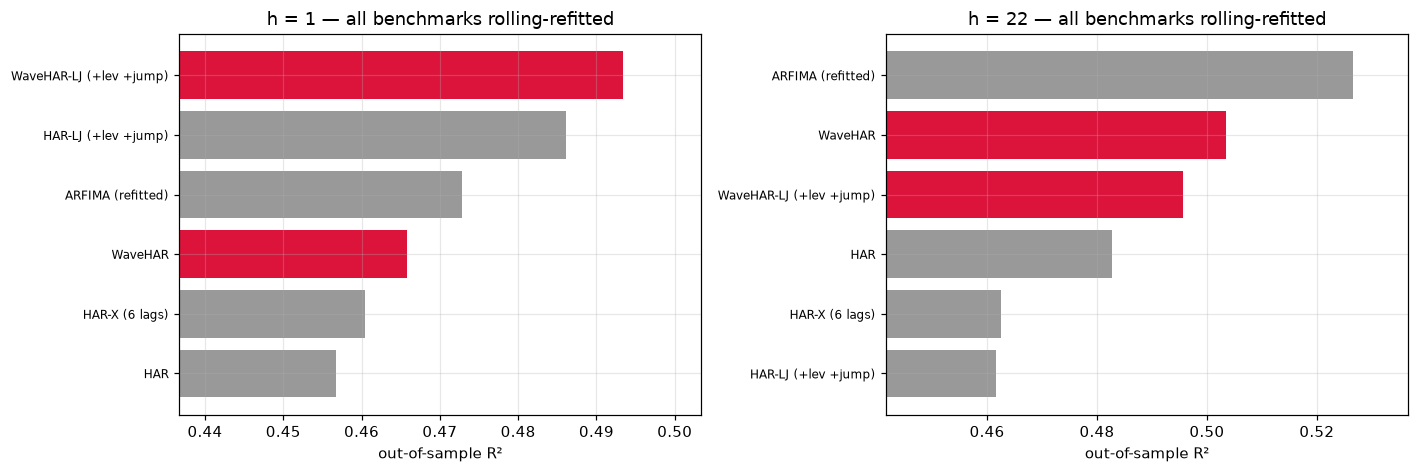

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, (res, h) in zip(axes, [(res1, H_MAIN), (res22, H_LONG)]):
    order = res.sort_values("R²")
    colors = ["crimson" if "WaveHAR" in m else "0.6" for m in order.index]
    ax.barh(range(len(order)), order["R²"], color=colors)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order.index, fontsize=8)
    ax.set_xlabel("out-of-sample R²")
    ax.set_title(f"h = {h} — all benchmarks rolling-refitted")
    ax.set_xlim(min(order["R²"]) - 0.02, max(order["R²"]) + 0.01)
plt.tight_layout()
plt.savefig("../figures/stress_test.png", dpi=140, bbox_inches="tight")
plt.show()

---
# Conclusion — printed from the results, whatever they say

In [13]:
def survives(verdicts, preds, y, name="WaveHAR"):
    beaten_by = [r for r, (s, p) in verdicts.items() if s > 0 and p < 0.05]
    beats = [r for r, (s, p) in verdicts.items() if s < 0 and p < 0.05]
    ties = [r for r, (s, p) in verdicts.items() if p >= 0.05]
    return beaten_by, beats, ties


print("=" * 78)
print("DID THE PART 3 RESULT SURVIVE?")
print("=" * 78)
for h, verd, pr, yy, res in [(H_MAIN, verdicts1, preds1, y1, res1),
                             (H_LONG, verdicts22, preds22, y22, res22)]:
    lost, won, tied = survives(verd, pr, yy)
    rank = list(res.index).index("WaveHAR") + 1
    print(f"\n  h = {h}:  WaveHAR ranks {rank}/{len(res)} by R² "
          f"({res.loc['WaveHAR', 'R²']:+.4f}; best is {res.index[0]} at {res['R²'].iloc[0]:+.4f})")
    print(f"     significantly beats     : {', '.join(won) if won else 'nothing'}")
    print(f"     significantly beaten by : {', '.join(lost) if lost else 'nothing'}")
    print(f"     statistically tied with : {', '.join(tied) if tied else 'nothing'}")

s1, p1 = verdicts1["HAR"]
s22, p22 = verdicts22["HAR"]
held_1 = s1 < 0 and p1 < 0.05
held_22 = s22 < 0 and p22 < 0.05

print()
print("=" * 78)
print("CLAIM 1 (Part 3's headline): plain WaveHAR beats plain HAR")
print("=" * 78)
print(f"   Part 3, HAR frozen on one fit   : DM p = 0.026 (h=1),  p = 0.004 (h=22)")
print(f"   Part 4, HAR rolling-refitted    : DM p = {p1:.3f} (h=1),  p = {p22:.3f} (h=22)")
print()
if held_1 and held_22:
    print("   → SURVIVES at both horizons.")
elif held_22 and not held_1:
    print("   → PARTLY BROKEN. At h=1 the advantage is no longer significant once HAR is refitted")
    print("     on a rolling window: part of what Part 3 measured really was a weakly fitted")
    print("     benchmark, exactly as Audrino & Chassot (2024) warn. At h=22 it survives, and")
    print("     survives strongly — which is where multiscale theory said the gain should be.")
    print("     The honest claim is NARROWER than the one Part 3 made, and this supersedes it.")
elif held_1 and not held_22:
    print("   → PARTLY BROKEN: survives at h=1 but not at the long horizon where Part 3 was most")
    print("     confident. That is the more damaging of the two failures.")
else:
    print("   → BROKEN. Once HAR is properly refitted, WaveHAR's advantage is gone at both")
    print("     horizons. Part 3 was beating a carelessly fitted benchmark. This supersedes it.")

s_lj1, p_lj1 = lj_verdicts[H_MAIN]
s_lj22, p_lj22 = lj_verdicts[H_LONG]
print()
print("=" * 78)
print("CLAIM 2 (the like-for-like test): the wavelet BASIS, with predictors matched")
print("=" * 78)
print(f"   HAR-LJ vs WaveHAR-LJ — same leverage & jump predictors on both sides:")
print(f"     h=1  : DM p = {p_lj1:.4f}   "
      f"({'wavelet basis better' if s_lj1 < 0 and p_lj1 < 0.05 else 'HAR basis better' if s_lj1 > 0 and p_lj1 < 0.05 else 'indistinguishable'})")
print(f"     h=22 : DM p = {p_lj22:.4f}   "
      f"({'wavelet basis better' if s_lj22 < 0 and p_lj22 < 0.05 else 'HAR basis better' if s_lj22 > 0 and p_lj22 < 0.05 else 'indistinguishable'})")
print(f"     across markets: WaveHAR-LJ > HAR-LJ in {wins_lj}/6 (significantly in {sig_lj}/6)")

print()
print("=" * 78)
print("WHAT ACTUALLY CAME OUT ON TOP")
print("=" * 78)
best1 = res1.index[0]
best22 = res22.index[0]
print(f"   h=1  best model: {best1}  (R² {res1['R²'].iloc[0]:+.4f})")
print(f"   h=22 best model: {best22}  (R² {res22['R²'].iloc[0]:+.4f})")
print()
print(f"   HAR, frozen fit (Part 3)          R² = +0.4629")
print(f"   HAR, rolling refit                R² = {res1.loc['HAR', 'R²']:+.4f}")
print(f"   HAR + leverage + jumps            R² = {res1.loc['HAR-LJ (+lev +jump)', 'R²']:+.4f}")
print(f"   WaveHAR, rolling refit            R² = {res1.loc['WaveHAR', 'R²']:+.4f}")
print(f"   WaveHAR + leverage + jumps        R² = {res1.loc['WaveHAR-LJ (+lev +jump)', 'R²']:+.4f}")
print()
print("   The single largest gain in this entire notebook came not from the wavelet and not from")
print("   the fitting scheme, but from ADDING LEVERAGE AND JUMP PREDICTORS — i.e. from knowing")
print("   the volatility literature, not from a fancier representation of the same information.")

DID THE PART 3 RESULT SURVIVE?

  h = 1:  WaveHAR ranks 4/6 by R² (+0.4658; best is WaveHAR-LJ (+lev +jump) at +0.4934)
     significantly beats     : nothing
     significantly beaten by : WaveHAR-LJ (+lev +jump)
     statistically tied with : HAR, HAR-X (6 lags), HAR-LJ (+lev +jump), ARFIMA (refitted)

  h = 22:  WaveHAR ranks 2/6 by R² (+0.5034; best is ARFIMA (refitted) at +0.5266)
     significantly beats     : HAR, HAR-X (6 lags)
     significantly beaten by : nothing
     statistically tied with : HAR-LJ (+lev +jump), WaveHAR-LJ (+lev +jump), ARFIMA (refitted)

CLAIM 1 (Part 3's headline): plain WaveHAR beats plain HAR
   Part 3, HAR frozen on one fit   : DM p = 0.026 (h=1),  p = 0.004 (h=22)
   Part 4, HAR rolling-refitted    : DM p = 0.133 (h=1),  p = 0.002 (h=22)

   → PARTLY BROKEN. At h=1 the advantage is no longer significant once HAR is refitted
     on a rolling window: part of what Part 3 measured really was a weakly fitted
     benchmark, exactly as Audrino & Chassot (

## Limitations I cannot fix here — stated plainly

**1. The volatility proxy is range-based, not high-frequency.** The literature's standard target is
realized variance built from **5-minute intraday returns** (Liu, Patton & Sheppard, 2015, *"Does
anything beat 5-minute RV?"*). I use the **Garman–Klass** estimator from daily OHLC bars, because
intraday data for six indices over fourteen years is not freely available. Range-based estimators
are legitimate and widely used, but they are **noisier** and considered a second-best proxy. A
noisier target compresses the differences between good models, so the margins in this notebook are
measured against a fuzzier yardstick than a high-frequency study would use. **This is the single
largest gap between this project and the published literature, and it is not closed here.**

**2. The jump and leverage components are daily-data analogues.** True HAR-J, SHAR and HARQ rely on
bipower variation, signed semivariances and realized quarticity — all of which require intraday
returns. My overnight-gap jump proxy and negative-return leverage proxy are defensible with daily
OHLC, and they are what a daily-data practitioner would actually use, but they are **not** the
canonical specifications and should not be described as such.

**3. HARQ is absent entirely**, for the same reason: it corrects for measurement error in RV using
realized quarticity, which daily bars cannot deliver.

**4. One split per market.** The fitting scheme is selected on a validation window, which is the
right procedure, but there is still a single out-of-sample period per asset. A full study would use
multiple rolling out-of-sample windows.

These are the honest boundaries of what this project establishes. Naming them is not a disclaimer
ritual — a reader who knows this literature will spot every one of them within a minute, and a
result is worth more when its author has already marked its edges.